In [2]:
!kaggle datasets download -d briscdataset/brisc2025
!unzip brisc2025.zip

Kết quả truyền trực tuyến bị cắt bớt đến 5000 dòng cuối.
  inflating: brisc2025/segmentation_task/train/images/brisc2025_train_03934_pi_ax_t1.jpg  
  inflating: brisc2025/segmentation_task/train/images/brisc2025_train_03935_pi_ax_t1.jpg  
  inflating: brisc2025/segmentation_task/train/images/brisc2025_train_03936_pi_ax_t1.jpg  
  inflating: brisc2025/segmentation_task/train/images/brisc2025_train_03937_pi_ax_t1.jpg  
  inflating: brisc2025/segmentation_task/train/images/brisc2025_train_03938_pi_ax_t1.jpg  
  inflating: brisc2025/segmentation_task/train/images/brisc2025_train_03939_pi_ax_t1.jpg  
  inflating: brisc2025/segmentation_task/train/images/brisc2025_train_03940_pi_ax_t1.jpg  
  inflating: brisc2025/segmentation_task/train/images/brisc2025_train_03941_pi_ax_t1.jpg  
  inflating: brisc2025/segmentation_task/train/images/brisc2025_train_03942_pi_ax_t1.jpg  
  inflating: brisc2025/segmentation_task/train/images/brisc2025_train_03943_pi_ax_t1.jpg  
  inflating: brisc2025/segmentati

In [3]:
pip install segmentation-models-pytorch timm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.5 MB/s eta 0:00:00


In [4]:
import os

print(os.listdir())

['.config', 'brisc2025.zip', 'brisc2025', 'sample_data']


In [5]:
for root, dirs, files in os.walk("brisc2025"):
    print(root)
    break

brisc2025


In [6]:
import os

base = "brisc2025/segmentation_task"

for split in ["train", "test"]:
    img_dir = os.path.join(base, split, "images")
    mask_dir = os.path.join(base, split, "masks")

    num_imgs = len(os.listdir(img_dir))
    num_masks = len(os.listdir(mask_dir))

    print(f"{split}:")
    print(f"  Images: {num_imgs}")
    print(f"  Masks : {num_masks}")

train:
  Images: 3933
  Masks : 3933
test:
  Images: 860
  Masks : 860


In [7]:
import os, cv2

img_dir = "brisc2025/segmentation_task/train/images"
mask_dir = "brisc2025/segmentation_task/train/masks"

imgs = sorted(os.listdir(img_dir))
masks = sorted(os.listdir(mask_dir))

# check pair
for i in range(5):
    print(imgs[i], masks[i])

brisc2025_train_00001_gl_ax_t1.jpg brisc2025_train_00001_gl_ax_t1.png
brisc2025_train_00002_gl_ax_t1.jpg brisc2025_train_00002_gl_ax_t1.png
brisc2025_train_00003_gl_ax_t1.jpg brisc2025_train_00003_gl_ax_t1.png
brisc2025_train_00004_gl_ax_t1.jpg brisc2025_train_00004_gl_ax_t1.png
brisc2025_train_00005_gl_ax_t1.jpg brisc2025_train_00005_gl_ax_t1.png


In [8]:
sizes = set()

for f in imgs:
    img = cv2.imread(os.path.join(img_dir, f), 0)
    sizes.add(img.shape)

print(sizes)

{(372, 341), (903, 721), (249, 206), (320, 257), (307, 257), (510, 485), (340, 507), (243, 208), (993, 825), (358, 314), (342, 290), (326, 273), (223, 226), (212, 226), (235, 200), (306, 306), (500, 455), (320, 497), (554, 554), (216, 214), (252, 200), (377, 341), (650, 591), (337, 305), (446, 450), (393, 313), (219, 224), (216, 216), (251, 201), (308, 262), (394, 295), (400, 400), (395, 367), (502, 502), (378, 360), (261, 232), (234, 215), (423, 630), (354, 289), (356, 286), (354, 298), (369, 503), (232, 217), (527, 552), (237, 213), (345, 338), (401, 312), (315, 315), (1427, 1275), (522, 513), (256, 256), (303, 252), (336, 264), (306, 278), (581, 528), (207, 201), (234, 219), (398, 351), (225, 225), (223, 200), (439, 645), (546, 472), (340, 291), (216, 234), (474, 474), (370, 374), (264, 420), (225, 209), (396, 402), (396, 411), (238, 212), (442, 442), (362, 507), (223, 202), (624, 491), (331, 272), (412, 300), (314, 329), (395, 366), (432, 470), (359, 300), (690, 722), (395, 341), (

In [9]:
import numpy as np

pixels = []

for f in imgs:
    img = cv2.imread(os.path.join(img_dir, f), 0)
    pixels.append(img.mean())

print("Mean intensity:", np.mean(pixels))

Mean intensity: 42.493842997981865


In [10]:
ratios = []

for f in masks:
    m = cv2.imread(os.path.join(mask_dir, f), 0)
    ratio = (m > 0).sum() / m.size
    ratios.append(ratio)

print("Avg tumor ratio:", np.mean(ratios))

Avg tumor ratio: 0.018347186836718824


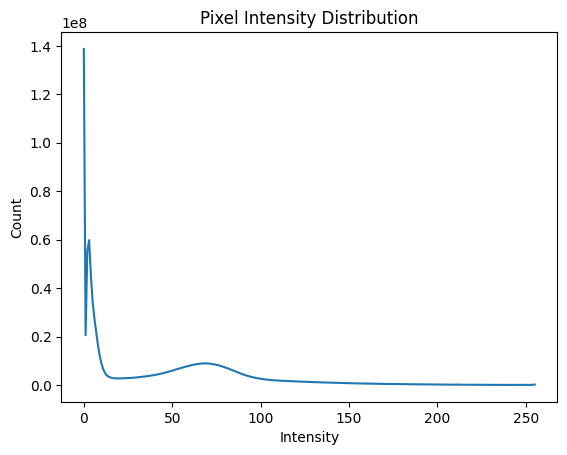

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os

hist = np.zeros(256)

for f in imgs:
    img = cv2.imread(os.path.join(img_dir, f), 0)
    h, _ = np.histogram(img, bins=256, range=(0,255))
    hist += h

plt.plot(hist)
plt.title("Pixel Intensity Distribution")
plt.xlabel("Intensity")
plt.ylabel("Count")
plt.show()

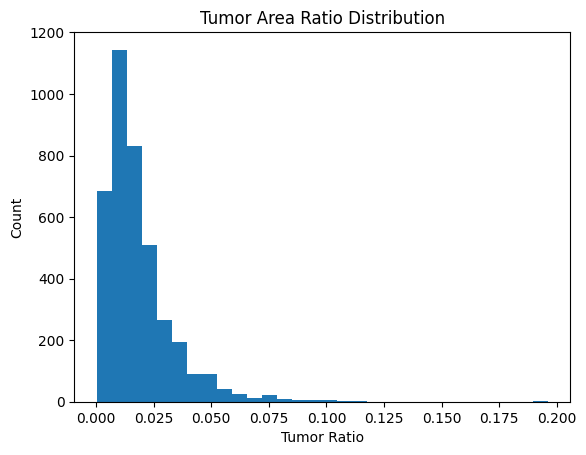

In [12]:
ratios = []

for f in masks:
    m = cv2.imread(os.path.join(mask_dir, f), 0)
    ratio = (m > 0).sum() / m.size
    ratios.append(ratio)

plt.hist(ratios, bins=30)
plt.title("Tumor Area Ratio Distribution")
plt.xlabel("Tumor Ratio")
plt.ylabel("Count")
plt.show()

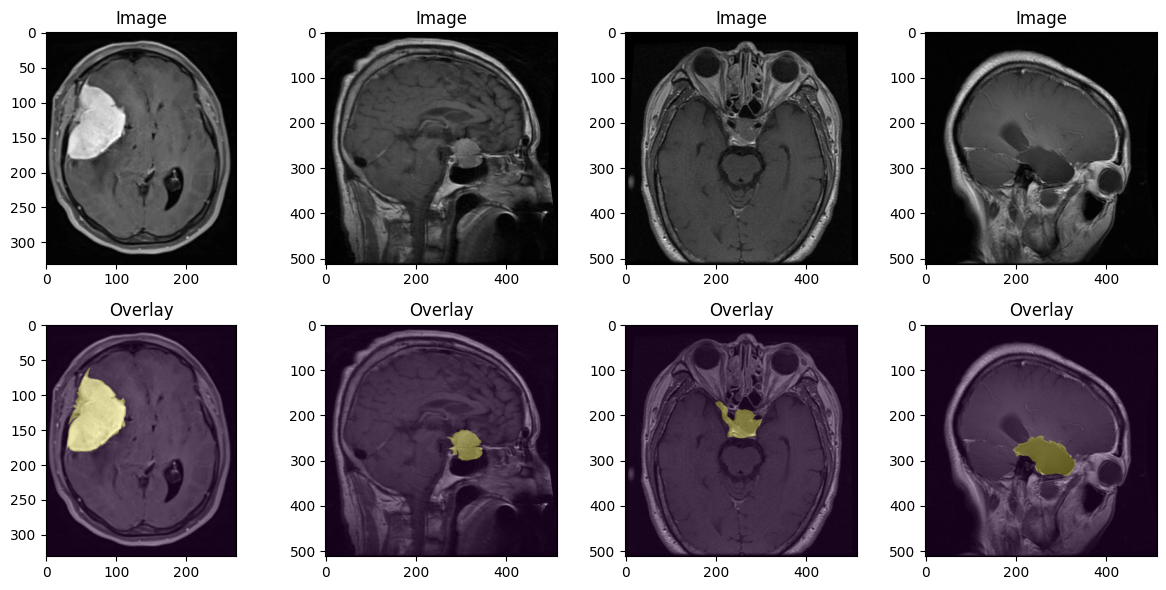

In [13]:
import random

idxs = random.sample(range(len(imgs)), 4)

plt.figure(figsize=(12,6))

for i, idx in enumerate(idxs):
    img = cv2.imread(os.path.join(img_dir, imgs[idx]), 0)
    mask = cv2.imread(os.path.join(mask_dir, masks[idx]), 0)

    plt.subplot(2,4,i+1)
    plt.imshow(img, cmap='gray')
    plt.title("Image")

    plt.subplot(2,4,i+5)
    plt.imshow(img, cmap='gray')
    plt.imshow(mask, alpha=0.3)
    plt.title("Overlay")

plt.tight_layout()
plt.show()

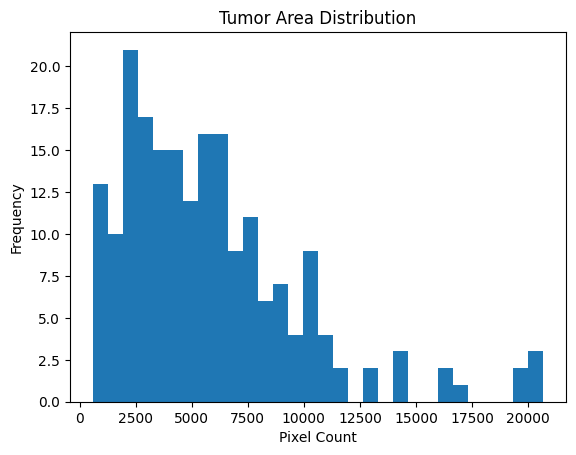

In [14]:
areas = []

for f in masks[:200]:
    m = cv2.imread(os.path.join(mask_dir, f), 0)
    areas.append((m > 0).sum())

plt.hist(areas, bins=30)
plt.title("Tumor Area Distribution")
plt.xlabel("Pixel Count")
plt.ylabel("Frequency")
plt.show()

In [15]:
import os, cv2, torch, numpy as np
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
import torch.optim as optim
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)

IMG_SIZE = 256
BATCH = 16
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

In [16]:
train_img_dir = "brisc2025/segmentation_task/train/images"
train_mask_dir= "brisc2025/segmentation_task/train/masks"

imgs  = sorted(os.listdir(train_img_dir))
masks = sorted(os.listdir(train_mask_dir))

tr_i, vl_i, tr_m, vl_m = train_test_split(
    imgs, masks, test_size=0.15, random_state=SEED
)

In [17]:
train_tf = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Rotate(limit=30, p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.Normalize(mean=(0.485,0.456,0.406),
                std =(0.229,0.224,0.225)),
    ToTensorV2()
])

val_tf = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485,0.456,0.406),
                std =(0.229,0.224,0.225)),
    ToTensorV2()
])

In [18]:
class BrainDataset(Dataset):
    def __init__(self, img_dir, mask_dir, imgs, masks, tf):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.imgs = imgs
        self.masks = masks
        self.tf = tf

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, i):
        img = cv2.imread(os.path.join(self.img_dir, self.imgs[i]))
        mask = cv2.imread(os.path.join(self.mask_dir, self.masks[i]), 0)

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        aug = self.tf(image=img, mask=mask)
        img, mask = aug["image"], aug["mask"]

        mask = (mask > 0).float().unsqueeze(0)

        return img, mask

In [19]:
train_ds = BrainDataset(train_img_dir, train_mask_dir, tr_i, tr_m, train_tf)
val_ds   = BrainDataset(train_img_dir, train_mask_dir, vl_i, vl_m, val_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True, num_workers=4)
val_loader   = DataLoader(val_ds, batch_size=BATCH, shuffle=False, num_workers=4)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [20]:
model = smp.Unet(
    encoder_name="timm-efficientnet-b4",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1
).to(DEVICE)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

In [21]:
tversky_loss = smp.losses.TverskyLoss(
    mode='binary',
    alpha=0.7,
    beta=0.3
)

bce_loss = smp.losses.SoftBCEWithLogitsLoss()

In [22]:
tversky_loss = smp.losses.TverskyLoss(
    mode='binary',
    alpha=0.7,
    beta=0.3
)

bce_loss = smp.losses.SoftBCEWithLogitsLoss()

In [23]:
def dice_score(pred, gt):
    inter = (pred*gt).sum()
    return (2*inter)/(pred.sum()+gt.sum()+1e-7)

In [24]:
def train_model(model, epochs=30):
    opt = optim.AdamW(model.parameters(), lr=2e-4)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)

    best = 0

    for ep in range(epochs):
        model.train()
        for x,y in train_loader:
            x,y = x.to(DEVICE), y.to(DEVICE)

            opt.zero_grad()
            out = model(x)
            loss = (
                    0.7 * tversky_loss(out, y)
                    + 0.3 * bce_loss(out, y)
                )
            loss.backward()
            opt.step()

        sch.step()

        # ===== VALIDATION =====
        model.eval()
        scores=[]

        with torch.no_grad():
            for x,y in val_loader:
                x,y = x.to(DEVICE), y.to(DEVICE)
                p = torch.sigmoid(model(x))
                pred = (p > 0.4).float()

                scores.append(dice_score(pred,y).item())

        vd = np.mean(scores)
        print(f"Epoch {ep} | Dice {vd:.4f}")

        if vd > best:
            best = vd
            torch.save(model.state_dict(), "best.pth")
            print(" saved")

In [25]:
train_model(model)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Epoch 0 | Dice 0.7380
 saved
Epoch 1 | Dice 0.8057
 saved
Epoch 2 | Dice 0.8119
 saved
Epoch 3 | Dice 0.8233
 saved
Epoch 4 | Dice 0.8449
 saved
Epoch 5 | Dice 0.8434
Epoch 6 | Dice 0.8408
Epoch 7 | Dice 0.8420
Epoch 8 | Dice 0.8564
 saved
Epoch 9 | Dice 0.8508
Epoch 10 | Dice 0.8493
Epoch 11 | Dice 0.8549
Epoch 12 | Dice 0.8464
Epoch 13 | Dice 0.8520
Epoch 14 | Dice 0.8498
Epoch 15 | Dice 0.8529
Epoch 16 | Dice 0.8443
Epoch 17 | Dice 0.8501
Epoch 18 | Dice 0.8569
 saved
Epoch 19 | Dice 0.8549
Epoch 20 | Dice 0.8539
Epoch 21 | Dice 0.8533
Epoch 22 | Dice 0.8589
 saved
Epoch 23 | Dice 0.8569
Epoch 24 | Dice 0.8594
 saved
Epoch 25 | Dice 0.8585
Epoch 26 | Dice 0.8584
Epoch 27 | Dice 0.8593
Epoch 28 | Dice 0.8591
Epoch 29 | Dice 0.8599
 saved


In [61]:
def tune_threshold():

    best_th = 0.5
    best_recall = 0

    for th in np.arange(0.001, 0.1, 0.002):

        recalls = []
        precisions = []

        with torch.no_grad():

            for x, y in val_loader:

                x = x.to(DEVICE)
                y = y.to(DEVICE)

                p = torch.sigmoid(
                    model(x)
                )

                pred = (
                    p > th
                ).float()

                for i in range(len(pred)):

                    pr = pred[i,0]
                    gt = y[i,0]

                    tp = (pr * gt).sum()

                    fp = (
                        pr * (1 - gt)
                    ).sum()

                    fn = (
                        (1 - pr) * gt
                    ).sum()

                    recall = tp / (
                        tp + fn + 1e-7
                    )

                    precision = tp / (
                        tp + fp + 1e-7
                    )

                    recalls.append(
                        recall.item()
                    )

                    precisions.append(
                        precision.item()
                    )

        mean_recall = np.mean(recalls)
        mean_precision = np.mean(precisions)

        print(
            f"TH={th:.3f} | "
            f"Recall={mean_recall:.4f} | "
            f"Precision={mean_precision:.4f}"
        )

        # ====================================
        # CONSTRAINT:
        # precision > 0.8
        # optimize recall
        # ====================================

        if mean_precision >= 0.80:

            if mean_recall > best_recall:

                best_recall = mean_recall
                best_th = th

    print("\nBest Threshold:", best_th)
    print("Best Recall:", best_recall)

    return best_th

In [62]:
model.load_state_dict(torch.load("best.pth"))
model.eval()

best_th = tune_threshold()

TH=0.001 | Recall=0.9320 | Precision=0.6632
TH=0.003 | Recall=0.8872 | Precision=0.7817
TH=0.005 | Recall=0.8689 | Precision=0.8170
TH=0.007 | Recall=0.8588 | Precision=0.8312
TH=0.009 | Recall=0.8526 | Precision=0.8402
TH=0.011 | Recall=0.8478 | Precision=0.8466
TH=0.013 | Recall=0.8443 | Precision=0.8494
TH=0.015 | Recall=0.8416 | Precision=0.8530
TH=0.017 | Recall=0.8392 | Precision=0.8559
TH=0.019 | Recall=0.8370 | Precision=0.8581
TH=0.021 | Recall=0.8352 | Precision=0.8603
TH=0.023 | Recall=0.8336 | Precision=0.8621
TH=0.025 | Recall=0.8323 | Precision=0.8638
TH=0.027 | Recall=0.8311 | Precision=0.8652
TH=0.029 | Recall=0.8299 | Precision=0.8665
TH=0.031 | Recall=0.8288 | Precision=0.8677
TH=0.033 | Recall=0.8277 | Precision=0.8688
TH=0.035 | Recall=0.8267 | Precision=0.8698
TH=0.037 | Recall=0.8257 | Precision=0.8708
TH=0.039 | Recall=0.8249 | Precision=0.8716
TH=0.041 | Recall=0.8241 | Precision=0.8723
TH=0.043 | Recall=0.8234 | Precision=0.8731
TH=0.045 | Recall=0.8227 | Preci

In [55]:
test_img_dir  = "brisc2025/segmentation_task/test/images"
test_mask_dir = "brisc2025/segmentation_task/test/masks"

test_imgs  = sorted(os.listdir(test_img_dir))
test_masks = sorted(os.listdir(test_mask_dir))

test_ds = BrainDataset(test_img_dir, test_mask_dir, test_imgs, test_masks, val_tf)

test_loader = DataLoader(test_ds, batch_size=BATCH, shuffle=False, num_workers=4)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [56]:
def compute_metrics(pred, gt):
    pred = pred.astype(np.float32)
    gt   = gt.astype(np.float32)

    tp = (pred * gt).sum()
    fp = (pred * (1 - gt)).sum()
    fn = ((1 - pred) * gt).sum()

    dice = (2*tp)/(2*tp+fp+fn+1e-7)
    recall = tp/(tp+fn+1e-7)
    precision = tp/(tp+fp+1e-7)
    f2 = (5*precision*recall)/(4*precision+recall+1e-7)

    return dice, recall, precision, f2

In [63]:
all_metrics = []

with torch.no_grad():
    for x,y in test_loader:
        x = x.to(DEVICE)
        p = torch.sigmoid(model(x)).cpu().numpy()
        y = y.numpy()

        for i in range(len(p)):
            pred = (p[i,0] > best_th).astype(np.uint8)
            gt   = (y[i,0] > 0).astype(np.uint8)

            all_metrics.append(compute_metrics(pred, gt))

all_metrics = np.array(all_metrics)

print("TEST RESULTS")
print("Dice      :", all_metrics[:,0].mean())
print("Recall    :", all_metrics[:,1].mean())
print("Precision :", all_metrics[:,2].mean())
print("F2        :", all_metrics[:,3].mean())

TEST RESULTS
Dice      : 0.83010966
Recall    : 0.88086057
Precision : 0.80701405
F2        : 0.8555356


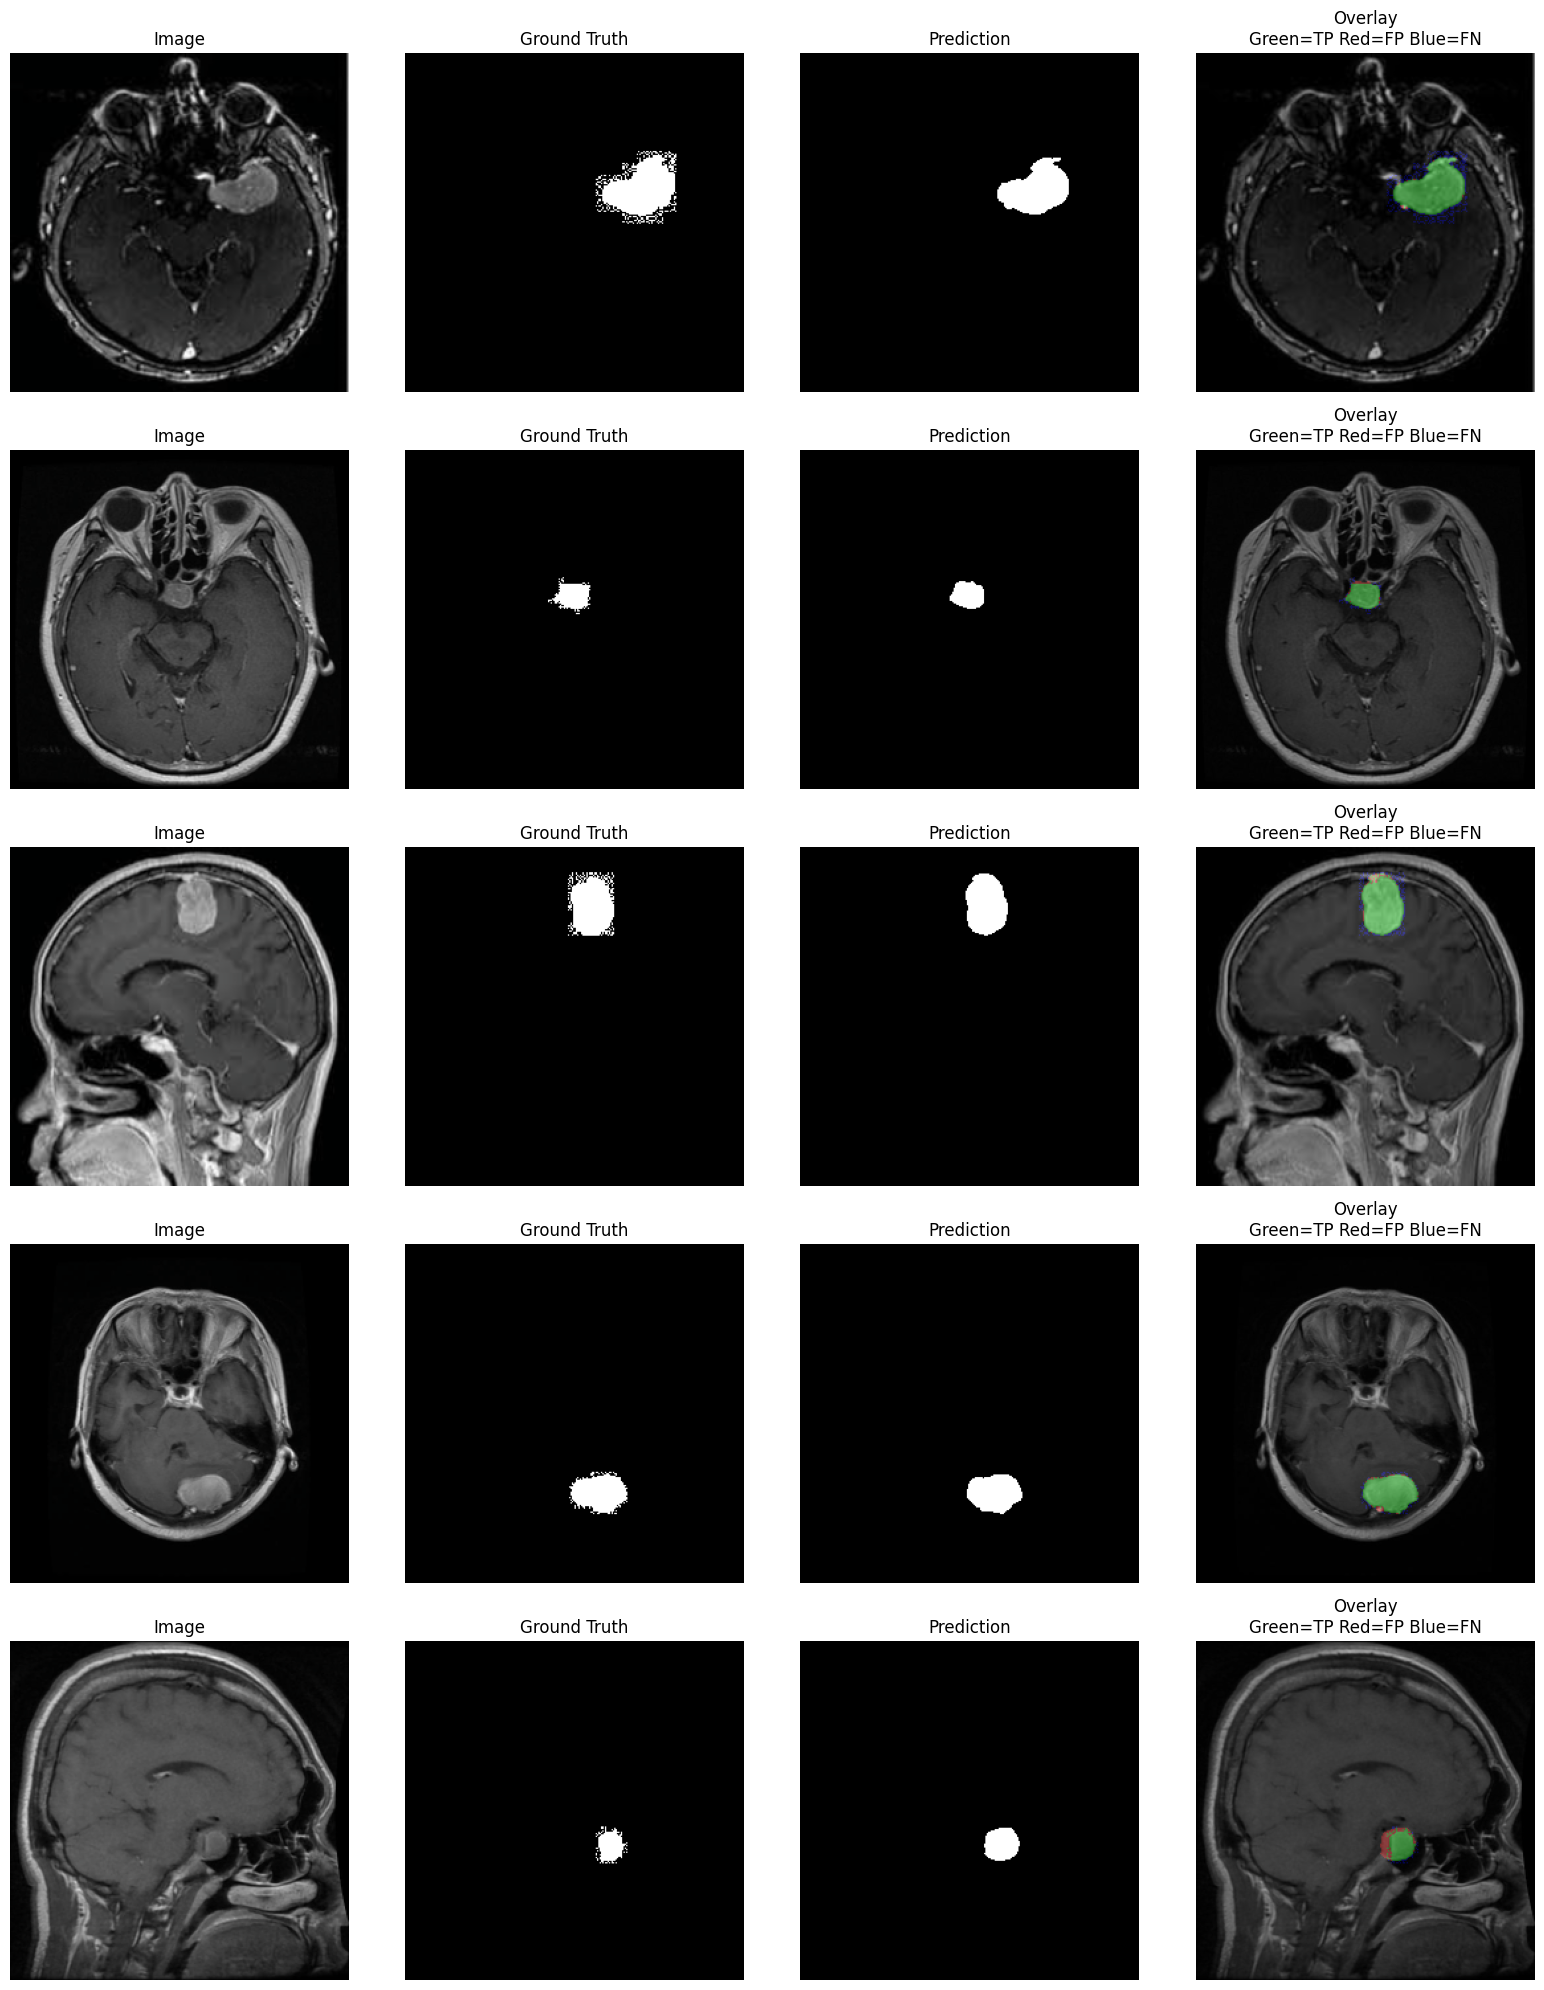

In [65]:
import random
import matplotlib.pyplot as plt

# ============================================
# RANDOM VISUALIZATION WITH ERROR OVERLAY
# ============================================

num_samples = 5

idxs = random.sample(
    range(len(test_ds)),
    num_samples
)

model.eval()

plt.figure(figsize=(16, num_samples*4))

with torch.no_grad():

    for row, idx in enumerate(idxs):


        img, mask = test_ds[idx]

        x = img.unsqueeze(0).to(DEVICE)


        pred = torch.sigmoid(
            model(x)
        )[0,0].cpu().numpy()

        pred = (
            pred > 0.3
        ).astype(np.uint8)

        gt = mask[0].numpy().astype(np.uint8)


        img_np = img.permute(1,2,0).numpy()

        mean = np.array([0.485,0.456,0.406])
        std  = np.array([0.229,0.224,0.225])

        img_np = (img_np * std) + mean

        img_np = np.clip(img_np, 0, 1)


        overlay = np.zeros_like(img_np)

        tp = (pred == 1) & (gt == 1)
        overlay[tp] = [0,1,0]

        fp = (pred == 1) & (gt == 0)
        overlay[fp] = [1,0,0]

        fn = (pred == 0) & (gt == 1)
        overlay[fn] = [0,0,1]

        blend = (
            0.7 * img_np
            +
            0.3 * overlay
        )

        blend = np.clip(blend, 0, 1)


        plt.subplot(num_samples, 4, row*4 + 1)

        plt.imshow(img_np)

        plt.title("Image")

        plt.axis("off")


        plt.subplot(num_samples, 4, row*4 + 2)

        plt.imshow(gt, cmap="gray")

        plt.title("Ground Truth")

        plt.axis("off")


        plt.subplot(num_samples, 4, row*4 + 3)

        plt.imshow(pred, cmap="gray")

        plt.title("Prediction")

        plt.axis("off")

        plt.subplot(num_samples, 4, row*4 + 4)

        plt.imshow(blend)

        plt.title(
            "Overlay\n"
            "Green=TP "
            "Red=FP "
            "Blue=FN"
        )

        plt.axis("off")

plt.tight_layout()

plt.show()